# Projeto Final - Equipe Vasco da Gama

- Juan Pablo do Egito Jimenez - 202307040009
- Samuel Meireles Maciejewsky - 202307040008
- Jose Antonio da Silva Pinto Junior - 202306840051

Este notebook reutiliza o ambiente `MassiveMIMOEnv` para treinar agentes de aprendizado por reforco na alocacao de potencia em uma rede Massive MIMO. O objetivo e comparar apenas PPO e DQN, em configuracao padrao e apos ajuste de hiperparametros com Optuna, usando metricas de recompensa, taxa de downlink, potencia e SINR do cenario.


## 1. Dependencias

A celula abaixo instala as bibliotecas usadas pelo notebook no ambiente Python do Jupyter.

In [2]:
%pip install -q stable-baselines3 optuna pandas matplotlib seaborn gymnasium numpy scipy numba torch

Note: you may need to restart the kernel to use updated packages.


## 2. Imports e caminhos


In [3]:
from pathlib import Path
from datetime import datetime
import json
import shutil
import sys
import time
import warnings

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import torch

from stable_baselines3 import DQN, PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.utils import set_random_seed

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("GPU CUDA nao detectada pelo kernel. O treino usara CPU.")

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "rl-wireless").exists() else NOTEBOOK_DIR.parent
RL_WIRELESS_DIR = PROJECT_ROOT / "rl-wireless"
sys.path.insert(0, str(RL_WIRELESS_DIR))

RESULTS_DIR = PROJECT_ROOT / "VASCO_final_project" / "results"
FIGURES_DIR = PROJECT_ROOT / "VASCO_final_project" / "figures"
MODELS_DIR = PROJECT_ROOT / "VASCO_final_project" / "models"
for directory in [RESULTS_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

from network import MassiveMIMOEnv


/home/juan/documents/projeto_ic_MIMO/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU detectada: NVIDIA GeForce RTX 2050


## 3. Configuracao do experimento

Nesta celula nossa equipe configura o cenario Massive MIMO e os parametros de treinamento de PPO e DQN. `FAST_MODE=True` usa uma configuracao leve para teste rapido; `FAST_MODE=False` usa uma execucao mais adequada para o relatorio.


In [4]:
SEED = 0
ENV_ID = "MassiveMIMO-v0"

ENV_CONFIG = {
    "N": 7,        # numero de celulas / BSs
    "M": 32,       # numero de antenas por BS
    "K": 4,        # numero de usuarios por celula
    "Ns": 10,      # amostras da realizacao do canal
    "min_P": -20,  # potencia minima em dBm
    "max_P": 23,   # potencia maxima em dBm
    "num_P": 10,   # niveis discretos de potencia
    "dtype": np.float32,
}

# Use True only for quick smoke tests. Final/report runs should keep False.
FAST_MODE = False

if FAST_MODE:
    DEFAULT_TRAIN_TIMESTEPS = 5_000
    OPTUNA_TRAIN_TIMESTEPS = 3_000
    FINAL_TRAIN_TIMESTEPS = 8_000
    N_TRIALS = 5
    EVAL_EPISODES = 10
    OPTUNA_PRUNER_EVAL_EPISODES = 5
else:
    DEFAULT_TRAIN_TIMESTEPS = 15_000
    OPTUNA_TRAIN_TIMESTEPS = 5_000
    FINAL_TRAIN_TIMESTEPS = 25_000
    N_TRIALS = 12
    EVAL_EPISODES = 15
    OPTUNA_PRUNER_EVAL_EPISODES = 5

OPTUNA_EVAL_FREQ = max(1_000, OPTUNA_TRAIN_TIMESTEPS // 4)
CUSTOM_RUN_ID = None  # Example: "20260720_final_run" to resume/reuse a named run.
RUN_ID = CUSTOM_RUN_ID or datetime.now().strftime("%Y%m%d_%H%M%S_vasco_ppo_dqn")

CLEAR_PREVIOUS_TOP_LEVEL_RESULTS = True
TOP_LEVEL_RESULT_FILES = [
    "summary_results.csv",
    "training_curves.csv",
    "evaluation_episodes.csv",
    "stability_summary.csv",
    "experiment_config.json",
    "scenario_power_levels.csv",
    "optuna_ppo_trials.csv",
    "optuna_dqn_trials.csv",
]
TOP_LEVEL_RESULT_DIRS = ["monitor", "tensorboard"]

TOP_LEVEL_FIGURE_FILES = [
    "learning_curves.png",
    "mean_reward_training.png",
    "min_reward_training.png",
    "reward_distribution.png",
    "final_comparison.png",
    "optuna_history.png",
    "optuna_param_importance.png",
    "stability_summary.png",
]

RUN_RESULTS_DIR = RESULTS_DIR / "runs" / RUN_ID
RUN_FIGURES_DIR = FIGURES_DIR / "runs" / RUN_ID
RUN_MODELS_DIR = MODELS_DIR / "runs" / RUN_ID
RUN_MONITOR_DIR = RUN_RESULTS_DIR / "monitor"
RUN_TENSORBOARD_DIR = RUN_RESULTS_DIR / "tensorboard"
RUN_OPTUNA_DB = RUN_RESULTS_DIR / "optuna_studies.sqlite3"

for directory in [RUN_RESULTS_DIR, RUN_FIGURES_DIR, RUN_MODELS_DIR, RUN_MONITOR_DIR, RUN_TENSORBOARD_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)
set_random_seed(SEED)

print({
    "run_id": RUN_ID,
    "fast_mode": FAST_MODE,
    "default_train_timesteps": DEFAULT_TRAIN_TIMESTEPS,
    "optuna_train_timesteps": OPTUNA_TRAIN_TIMESTEPS,
    "final_train_timesteps": FINAL_TRAIN_TIMESTEPS,
    "n_trials": N_TRIALS,
    "eval_episodes": EVAL_EPISODES,
    "optuna_pruner_eval_episodes": OPTUNA_PRUNER_EVAL_EPISODES,
    "optuna_eval_freq": OPTUNA_EVAL_FREQ,
    "device": DEVICE,
    "run_results_dir": str(RUN_RESULTS_DIR),
    "run_models_dir": str(RUN_MODELS_DIR),
    "run_figures_dir": str(RUN_FIGURES_DIR),
})


{'run_id': '20260720_210926_vasco_ppo_dqn', 'fast_mode': False, 'default_train_timesteps': 15000, 'optuna_train_timesteps': 5000, 'final_train_timesteps': 25000, 'n_trials': 12, 'eval_episodes': 15, 'optuna_pruner_eval_episodes': 5, 'optuna_eval_freq': 1250, 'device': 'cuda', 'run_results_dir': '/home/juan/documents/projeto_ic_MIMO/VASCO_final_project/results/runs/20260720_210926_vasco_ppo_dqn', 'run_models_dir': '/home/juan/documents/projeto_ic_MIMO/VASCO_final_project/models/runs/20260720_210926_vasco_ppo_dqn', 'run_figures_dir': '/home/juan/documents/projeto_ic_MIMO/VASCO_final_project/figures/runs/20260720_210926_vasco_ppo_dqn'}


## 4. Registro e validacao do ambiente Gymnasium

In [5]:
from gymnasium.envs.registration import registry

if ENV_ID not in registry:
    gym.register(id=ENV_ID, entry_point="network.environment:MassiveMIMOEnv")

def make_env(seed=None):
    env = gym.make(ENV_ID, **ENV_CONFIG)
    if seed is not None:
        env.reset(seed=seed)
        env.action_space.seed(seed)
    return env

def make_monitored_vec_env(name, seed=None):
    log_dir = RUN_MONITOR_DIR / name
    log_dir.mkdir(parents=True, exist_ok=True)

    def _init():
        env = make_env(seed=seed)
        return Monitor(env, filename=str(log_dir / f"{name}.monitor.csv"), override_existing=True)

    return DummyVecEnv([_init])

def watts_to_dbm_value(power_watts):
    if power_watts <= 0:
        return -np.inf
    return 10.0 * np.log10(power_watts * 1_000.0)

def linear_to_db_value(value):
    if value <= 0:
        return -np.inf
    return 10.0 * np.log10(value)

env_check = make_env(seed=SEED)
check_env(env_check.unwrapped, warn=True)
obs, info = env_check.reset(seed=SEED)
action = env_check.action_space.sample()
next_obs, reward, terminated, truncated, info = env_check.step(action)
env_check.close()

env_preview = make_env()
power_levels_watts = np.asarray(env_preview.unwrapped.action_value, dtype=float)
power_levels_df = pd.DataFrame({
    "action": np.arange(len(power_levels_watts)),
    "power_watts": power_levels_watts,
    "power_dbm": [watts_to_dbm_value(power) for power in power_levels_watts],
})
power_levels_df.to_csv(RUN_RESULTS_DIR / "scenario_power_levels.csv", index=False)

scenario_summary = {
    "celulas_bs": ENV_CONFIG["N"],
    "antenas_por_bs": ENV_CONFIG["M"],
    "usuarios_por_celula": ENV_CONFIG["K"],
    "amostras_canal": ENV_CONFIG["Ns"],
    "potencia_min_dbm": ENV_CONFIG["min_P"],
    "potencia_max_dbm": ENV_CONFIG["max_P"],
    "niveis_discretos_potencia": ENV_CONFIG["num_P"],
}

print("Observation space:", env_preview.observation_space)
print("Action space:", env_preview.action_space)
print("Resumo do cenario:", scenario_summary)
print("Exemplo de observacao inicial:", obs)
print("Exemplo de acao:", action)
print("Exemplo de recompensa:", reward)
print("Potencia selecionada no exemplo (W):", float(next_obs[0]))
print("Potencia selecionada no exemplo (dBm):", watts_to_dbm_value(float(next_obs[0])))
print("SINR medio no exemplo (linear):", float(next_obs[1]))
print("SINR medio no exemplo (dB):", linear_to_db_value(float(next_obs[1])))
print("Shape de downlink_rate:", np.asarray(info["downlink_rate"]).shape)
display(power_levels_df)
env_preview.close()


Observation space: Box([-2.0000000e+01 -3.4028235e+38 -3.4028235e+38], [2.3000000e+01 3.4028235e+38 3.4028235e+38], (3,), float32)
Action space: Discrete(10)
Resumo do cenario: {'celulas_bs': 7, 'antenas_por_bs': 32, 'usuarios_por_celula': 4, 'amostras_canal': 10, 'potencia_min_dbm': -20, 'potencia_max_dbm': 23, 'niveis_discretos_potencia': 10}
Exemplo de observacao inicial: [ 0.04199028 -0.04022276 -0.03430095]
Exemplo de acao: 9
Exemplo de recompensa: 2.721829718143411
Potencia selecionada no exemplo (W): 0.19952623546123505
Potencia selecionada no exemplo (dBm): 23.000000086289106
SINR medio no exemplo (linear): 15.017603874206543
SINR medio no exemplo (dB): 11.76600644570696
Shape de downlink_rate: (7, 4)


,action,power_watts,power_dbm
0,0,0.000000,-inf
1,1,0.000010,-20.000
2,2,0.000034,-14.625
3,3,0.000119,-9.250
4,4,0.000410,-3.875
5,5,0.001413,1.500
6,6,0.004870,6.875
7,7,0.016788,12.250
8,8,0.057876,17.625
9,9,0.199526,23.000


## 5. Funcoes de treino e avaliacao

In [6]:
def watts_to_dbm(power_watts):
    power = np.asarray(power_watts, dtype=float)
    dbm = np.full(power.shape, -np.inf, dtype=float)
    mask = power > 0
    dbm[mask] = 10.0 * np.log10(power[mask] * 1_000.0)
    if np.isscalar(power_watts):
        return float(dbm.item())
    return dbm

def linear_to_db(value):
    linear = np.asarray(value, dtype=float)
    db = np.full(linear.shape, -np.inf, dtype=float)
    mask = linear > 0
    db[mask] = 10.0 * np.log10(linear[mask])
    if np.isscalar(value):
        return float(db.item())
    return db

def evaluate_policy(model, n_episodes=EVAL_EPISODES, seed=SEED, deterministic=True):
    env = make_env(seed=seed)
    episode_records = []

    for episode in range(n_episodes):
        episode_seed = seed + episode
        obs, info = env.reset(seed=episode_seed)
        terminated = False
        truncated = False
        total_reward = 0.0
        rates = []
        powers_watts = []
        sinrs_linear = []
        actions = []

        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=deterministic)
            if isinstance(action, np.ndarray):
                action = int(action.item())
            else:
                action = int(action)

            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += float(reward)
            rates.append(float(np.mean(info["downlink_rate"])))
            powers_watts.append(float(obs[0]))
            sinrs_linear.append(float(obs[1]))
            actions.append(action)

        mean_power_watts = float(np.mean(powers_watts))
        mean_sinr_linear = float(np.mean(sinrs_linear))
        episode_records.append({
            "episode": episode + 1,
            "episode_seed": episode_seed,
            "reward": float(total_reward),
            "mean_downlink_rate": float(np.mean(rates)),
            "mean_power_watts": mean_power_watts,
            "mean_power_dbm": watts_to_dbm(mean_power_watts),
            "mean_sinr_linear": mean_sinr_linear,
            "mean_sinr_db": linear_to_db(mean_sinr_linear),
            "zero_power_fraction": float(np.mean(np.array(actions) == 0)),
            "most_used_action": int(pd.Series(actions).mode().iloc[0]),
            "deterministic": deterministic,
        })

    env.close()
    rewards = np.array([row["reward"] for row in episode_records], dtype=float)
    rates = np.array([row["mean_downlink_rate"] for row in episode_records], dtype=float)
    powers_watts = np.array([row["mean_power_watts"] for row in episode_records], dtype=float)
    powers_dbm = np.array([row["mean_power_dbm"] for row in episode_records], dtype=float)
    sinrs_linear = np.array([row["mean_sinr_linear"] for row in episode_records], dtype=float)
    sinrs_db = np.array([row["mean_sinr_db"] for row in episode_records], dtype=float)
    zero_power_fraction = np.array([row["zero_power_fraction"] for row in episode_records], dtype=float)

    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "min_reward": float(np.min(rewards)),
        "max_reward": float(np.max(rewards)),
        "mean_downlink_rate": float(np.mean(rates)),
        "std_downlink_rate": float(np.std(rates)),
        "mean_power_watts": float(np.mean(powers_watts)),
        "std_power_watts": float(np.std(powers_watts)),
        "mean_power_dbm": float(np.mean(powers_dbm)),
        "std_power_dbm": float(np.std(powers_dbm)),
        "mean_sinr_linear": float(np.mean(sinrs_linear)),
        "std_sinr_linear": float(np.std(sinrs_linear)),
        "mean_sinr_db": float(np.mean(sinrs_db)),
        "std_sinr_db": float(np.std(sinrs_db)),
        "zero_power_fraction": float(np.mean(zero_power_fraction)),
        "episodes": episode_records,
    }

class OptunaEvalCallback(BaseCallback):
    def __init__(self, trial, eval_freq, n_eval_episodes, eval_seed, verbose=0):
        super().__init__(verbose=verbose)
        self.trial = trial
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.eval_seed = eval_seed
        self.is_pruned = False
        self.last_mean_reward = None

    def _on_step(self):
        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            metrics = evaluate_policy(
                self.model,
                n_episodes=self.n_eval_episodes,
                seed=self.eval_seed + self.n_calls,
                deterministic=True,
            )
            self.last_mean_reward = metrics["mean_reward"]
            self.trial.report(self.last_mean_reward, step=self.n_calls)
            if self.trial.should_prune():
                self.is_pruned = True
                return False
        return True

def train_model(algorithm_cls, name, params, total_timesteps, seed=SEED, callback=None, save_model=True):
    set_random_seed(seed)
    env = make_monitored_vec_env(name=name, seed=seed)
    model = algorithm_cls(
        "MlpPolicy",
        env,
        seed=seed,
        verbose=0,
        device=DEVICE,
        tensorboard_log=str(RUN_TENSORBOARD_DIR),
        **params,
    )

    start = time.perf_counter()
    model.learn(total_timesteps=total_timesteps, progress_bar=False, callback=callback)
    train_time_s = time.perf_counter() - start
    if save_model and not getattr(callback, "is_pruned", False):
        model.save(str(RUN_MODELS_DIR / name))
    env.close()
    return model, train_time_s

def result_row(model_name, algorithm, training_type, metrics, params=None, train_time_s=None, seed=SEED):
    return {
        "run_id": RUN_ID,
        "model": model_name,
        "algorithm": algorithm,
        "training_type": training_type,
        "seed": seed,
        "eval_episodes": EVAL_EPISODES,
        "mean_reward": metrics["mean_reward"],
        "std_reward": metrics["std_reward"],
        "min_reward": metrics["min_reward"],
        "max_reward": metrics["max_reward"],
        "mean_downlink_rate": metrics["mean_downlink_rate"],
        "std_downlink_rate": metrics["std_downlink_rate"],
        "mean_power_watts": metrics["mean_power_watts"],
        "std_power_watts": metrics["std_power_watts"],
        "mean_power_dbm": metrics["mean_power_dbm"],
        "std_power_dbm": metrics["std_power_dbm"],
        "mean_sinr_linear": metrics["mean_sinr_linear"],
        "std_sinr_linear": metrics["std_sinr_linear"],
        "mean_sinr_db": metrics["mean_sinr_db"],
        "std_sinr_db": metrics["std_sinr_db"],
        "zero_power_fraction": metrics["zero_power_fraction"],
        "train_time_s": train_time_s,
        "device": DEVICE,
        "params": params or {},
    }


In [7]:
all_results = []
evaluation_records = []

if CLEAR_PREVIOUS_TOP_LEVEL_RESULTS:
    for filename in TOP_LEVEL_RESULT_FILES:
        path = RESULTS_DIR / filename
        if path.exists():
            path.unlink()
    for dirname in TOP_LEVEL_RESULT_DIRS:
        path = RESULTS_DIR / dirname
        if path.exists():
            shutil.rmtree(path)
    for filename in TOP_LEVEL_FIGURE_FILES:
        path = FIGURES_DIR / filename
        if path.exists():
            path.unlink()
    for path in MODELS_DIR.glob("*.zip"):
        path.unlink()

def json_default(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, type):
        return value.__name__
    if isinstance(value, np.dtype):
        return str(value)
    if value is np.float32:
        return "float32"
    if isinstance(value, np.generic):
        return value.item()
    return str(value)

def save_experiment_config():
    config = {
        "run_id": RUN_ID,
        "seed": SEED,
        "env_id": ENV_ID,
        "env_config": ENV_CONFIG,
        "fast_mode": FAST_MODE,
        "default_train_timesteps": DEFAULT_TRAIN_TIMESTEPS,
        "optuna_train_timesteps": OPTUNA_TRAIN_TIMESTEPS,
        "final_train_timesteps": FINAL_TRAIN_TIMESTEPS,
        "n_trials": N_TRIALS,
        "eval_episodes": EVAL_EPISODES,
        "optuna_pruner_eval_episodes": OPTUNA_PRUNER_EVAL_EPISODES,
        "optuna_eval_freq": OPTUNA_EVAL_FREQ,
        "device": DEVICE,
        "run_results_dir": RUN_RESULTS_DIR,
        "run_models_dir": RUN_MODELS_DIR,
        "run_figures_dir": RUN_FIGURES_DIR,
    }
    with open(RUN_RESULTS_DIR / "experiment_config.json", "w", encoding="utf-8") as f:
        json.dump(config, f, indent=2, default=json_default)

save_experiment_config()

def record_result(model_name, algorithm, training_type, metrics, params=None, train_time_s=None, seed=SEED):
    all_results.append(result_row(model_name, algorithm, training_type, metrics, params, train_time_s, seed=seed))
    for episode_row in metrics["episodes"]:
        evaluation_records.append({
            "run_id": RUN_ID,
            "model": model_name,
            "algorithm": algorithm,
            "training_type": training_type,
            "seed": seed,
            **episode_row,
        })

def save_result_tables():
    results_df = pd.DataFrame(all_results)
    evaluation_df = pd.DataFrame(evaluation_records)

    if not results_df.empty:
        results_df.to_csv(RUN_RESULTS_DIR / "summary_results.csv", index=False)
    if not evaluation_df.empty:
        evaluation_df.to_csv(RUN_RESULTS_DIR / "evaluation_episodes.csv", index=False)

    if not evaluation_df.empty:
        stability_df = (
            evaluation_df.groupby(["run_id", "model", "algorithm", "training_type"], as_index=False)
            .agg(
                mean_reward=("reward", "mean"),
                std_reward=("reward", "std"),
                min_reward=("reward", "min"),
                max_reward=("reward", "max"),
                mean_downlink_rate=("mean_downlink_rate", "mean"),
                std_downlink_rate=("mean_downlink_rate", "std"),
                mean_power_watts=("mean_power_watts", "mean"),
                std_power_watts=("mean_power_watts", "std"),
                mean_power_dbm=("mean_power_dbm", "mean"),
                std_power_dbm=("mean_power_dbm", "std"),
                mean_sinr_linear=("mean_sinr_linear", "mean"),
                std_sinr_linear=("mean_sinr_linear", "std"),
                mean_sinr_db=("mean_sinr_db", "mean"),
                std_sinr_db=("mean_sinr_db", "std"),
                zero_power_fraction=("zero_power_fraction", "mean"),
                episodes=("episode", "count"),
            )
        )
        stability_df.to_csv(RUN_RESULTS_DIR / "stability_summary.csv", index=False)

    return results_df

def publish_latest_artifacts():
    for filename in TOP_LEVEL_RESULT_FILES:
        source = RUN_RESULTS_DIR / filename
        if source.exists():
            shutil.copy2(source, RESULTS_DIR / filename)
    for source in RUN_FIGURES_DIR.glob("*.png"):
        shutil.copy2(source, FIGURES_DIR / source.name)
    for source in RUN_MODELS_DIR.glob("*.zip"):
        shutil.copy2(source, MODELS_DIR / source.name)

print("Resultados desta execucao serao salvos em:", RUN_RESULTS_DIR)


Resultados desta execucao serao salvos em: /home/juan/documents/projeto_ic_MIMO/VASCO_final_project/results/runs/20260720_210926_vasco_ppo_dqn


## 6. Treinamento padrao: PPO e DQN


In [8]:
ppo_default_params = {
    "learning_rate": 3e-4,
    "n_steps": 256,
    "batch_size": 64,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "clip_range": 0.2,
    "ent_coef": 0.0,
}

dqn_default_params = {
    "learning_rate": 1e-3,
    "buffer_size": 50_000,
    "learning_starts": 1_000,
    "batch_size": 64,
    "gamma": 0.99,
    "train_freq": 4,
    "gradient_steps": 1,
    "target_update_interval": 500,
    "exploration_fraction": 0.2,
    "exploration_final_eps": 0.05,
}

ppo_default, ppo_default_time = train_model(PPO, "ppo_default", ppo_default_params, DEFAULT_TRAIN_TIMESTEPS)
ppo_default_metrics = evaluate_policy(ppo_default, n_episodes=EVAL_EPISODES, seed=SEED, deterministic=True)
record_result("ppo_default", "PPO", "default", ppo_default_metrics, ppo_default_params, ppo_default_time)

dqn_default, dqn_default_time = train_model(DQN, "dqn_default", dqn_default_params, DEFAULT_TRAIN_TIMESTEPS)
dqn_default_metrics = evaluate_policy(dqn_default, n_episodes=EVAL_EPISODES, seed=SEED, deterministic=True)
record_result("dqn_default", "DQN", "default", dqn_default_metrics, dqn_default_params, dqn_default_time)

results_df = save_result_tables()
results_df.drop(columns=["params"])


,run_id,model,algorithm,training_type,seed,eval_episodes,mean_reward,std_reward,min_reward,max_reward,...,std_power_watts,mean_power_dbm,std_power_dbm,mean_sinr_linear,std_sinr_linear,mean_sinr_db,std_sinr_db,zero_power_fraction,train_time_s,device
0,20260720_210926_vasco_ppo_dqn,ppo_default,PPO,default,0,15,24.448214,3.434583,17.503733,28.389049,...,0.0,23.0,0.0,21.656195,14.95006,12.443033,2.813854,0.0,457.656226,cuda
1,20260720_210926_vasco_ppo_dqn,dqn_default,DQN,default,0,15,23.132946,3.258342,16.887224,29.626390,...,0.0,23.0,0.0,15.590226,7.59645,11.291103,2.520022,0.0,315.024110,cuda


## 7. Tuning com Optuna - PPO

In [9]:
def sample_ppo_params(trial):
    n_steps = trial.suggest_categorical("n_steps", [256, 512, 1024, 2048])
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
    if batch_size > n_steps:
        batch_size = n_steps
    return {
        "learning_rate": trial.suggest_float("learning_rate", 3e-5, 3e-3, log=True),
        "n_steps": n_steps,
        "batch_size": batch_size,
        "gamma": trial.suggest_float("gamma", 0.93, 0.999),
        "gae_lambda": trial.suggest_float("gae_lambda", 0.85, 0.99),
        "clip_range": trial.suggest_float("clip_range", 0.10, 0.30),
        "ent_coef": trial.suggest_float("ent_coef", 0.0, 0.01),
    }

def objective_ppo(trial):
    params = sample_ppo_params(trial)
    model_name = f"optuna_ppo_trial_{trial.number:03d}"
    callback = OptunaEvalCallback(
        trial,
        eval_freq=OPTUNA_EVAL_FREQ,
        n_eval_episodes=OPTUNA_PRUNER_EVAL_EPISODES,
        eval_seed=SEED + 1000 + trial.number,
    )
    model, train_time_s = train_model(
        PPO,
        model_name,
        params,
        OPTUNA_TRAIN_TIMESTEPS,
        seed=SEED + trial.number,
        callback=callback,
        save_model=False,
    )
    if callback.is_pruned:
        raise optuna.TrialPruned()
    metrics = evaluate_policy(model, n_episodes=EVAL_EPISODES, seed=SEED + 1000 + trial.number, deterministic=True)
    trial.set_user_attr("mean_downlink_rate", metrics["mean_downlink_rate"])
    trial.set_user_attr("mean_power_dbm", metrics["mean_power_dbm"])
    trial.set_user_attr("mean_sinr_db", metrics["mean_sinr_db"])
    trial.set_user_attr("std_reward", metrics["std_reward"])
    trial.set_user_attr("train_time_s", train_time_s)
    return metrics["mean_reward"]

study_ppo = optuna.create_study(
    direction="maximize",
    study_name="vasco_ppo_tuning",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=OPTUNA_EVAL_FREQ),
    storage=f"sqlite:///{RUN_OPTUNA_DB}",
    load_if_exists=True,
)
study_ppo.optimize(objective_ppo, n_trials=N_TRIALS, n_jobs=1, show_progress_bar=True)

print("Melhor recompensa PPO:", study_ppo.best_value)
print("Melhores hiperparametros PPO:")
study_ppo.best_params


[I 2026-07-20 21:22:30,179] A new study created in RDB with name: vasco_ppo_tuning
Best trial: 0. Best value: 25.1016:   8%|▊         | 1/12 [02:45<30:15, 165.05s/it]

[I 2026-07-20 21:25:15,221] Trial 0 finished with value: 25.10155713003713 and parameters: {'n_steps': 512, 'batch_size': 256, 'learning_rate': 0.002537737958414811, 'gamma': 0.9564574647989786, 'gae_lambda': 0.9608415053315731, 'clip_range': 0.2057789839505809, 'ent_coef': 0.0056804456109393235}. Best is trial 0 with value: 25.10155713003713.


Best trial: 0. Best value: 25.1016:  17%|█▋        | 2/12 [05:25<27:05, 162.52s/it]

[I 2026-07-20 21:27:55,978] Trial 1 finished with value: 23.864000220013143 and parameters: {'n_steps': 256, 'batch_size': 256, 'learning_rate': 0.0011897025245313022, 'gamma': 0.9618420759954524, 'gae_lambda': 0.9592740846801038, 'clip_range': 0.12365488517378664, 'ent_coef': 0.006399210213275238}. Best is trial 0 with value: 25.10155713003713.


Best trial: 0. Best value: 25.1016:  25%|██▌       | 3/12 [08:08<24:23, 162.63s/it]

...

Best trial: 3. Best value: 26.1575:  92%|█████████▏| 11/12 [29:59<02:10, 130.05s/it]

[I 2026-07-20 21:52:29,400] Trial 10 pruned. 


Best trial: 3. Best value: 26.1575: 100%|██████████| 12/12 [32:54<00:00, 164.51s/it]

[I 2026-07-20 21:55:24,281] Trial 11 finished with value: 23.093534000472896 and parameters: {'n_steps': 256, 'batch_size': 32, 'learning_rate': 7.671146210447024e-05, 'gamma': 0.9441820863721859, 'gae_lambda': 0.9870581991308, 'clip_range': 0.11352878074848871, 'ent_coef': 0.0007020039193428179}. Best is trial 3 with value: 26.157511619907872.
Melhor recompensa PPO: 26.157511619907872
Melhores hiperparametros PPO:


{'n_steps': 2048,
 'batch_size': 128,
 'learning_rate': 5.432176219989315e-05,
 'gamma': 0.9517645562137688,
 'gae_lambda': 0.9009195079319672,
 'clip_range': 0.21403935408357594,
 'ent_coef': 0.004386015134623203}

## 8. Tuning com Optuna - DQN

In [10]:
def sample_dqn_params(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True),
        "buffer_size": trial.suggest_categorical("buffer_size", [50_000, 100_000, 150_000]),
        "learning_starts": trial.suggest_categorical("learning_starts", [500, 1_000, 2_000]),
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256]),
        "gamma": trial.suggest_float("gamma", 0.93, 0.999),
        "train_freq": trial.suggest_categorical("train_freq", [1, 4, 8]),
        "gradient_steps": trial.suggest_categorical("gradient_steps", [1, 2, 4]),
        "target_update_interval": trial.suggest_categorical("target_update_interval", [500, 1_000, 2_000]),
        "exploration_fraction": trial.suggest_float("exploration_fraction", 0.10, 0.40),
        "exploration_final_eps": trial.suggest_float("exploration_final_eps", 0.01, 0.08),
    }

def objective_dqn(trial):
    params = sample_dqn_params(trial)
    model_name = f"optuna_dqn_trial_{trial.number:03d}"
    callback = OptunaEvalCallback(
        trial,
        eval_freq=OPTUNA_EVAL_FREQ,
        n_eval_episodes=OPTUNA_PRUNER_EVAL_EPISODES,
        eval_seed=SEED + 2000 + trial.number,
    )
    model, train_time_s = train_model(
        DQN,
        model_name,
        params,
        OPTUNA_TRAIN_TIMESTEPS,
        seed=SEED + 100 + trial.number,
        callback=callback,
        save_model=False,
    )
    if callback.is_pruned:
        raise optuna.TrialPruned()
    metrics = evaluate_policy(model, n_episodes=EVAL_EPISODES, seed=SEED + 2000 + trial.number, deterministic=True)
    trial.set_user_attr("mean_downlink_rate", metrics["mean_downlink_rate"])
    trial.set_user_attr("mean_power_dbm", metrics["mean_power_dbm"])
    trial.set_user_attr("mean_sinr_db", metrics["mean_sinr_db"])
    trial.set_user_attr("std_reward", metrics["std_reward"])
    trial.set_user_attr("train_time_s", train_time_s)
    return metrics["mean_reward"]

study_dqn = optuna.create_study(
    direction="maximize",
    study_name="vasco_dqn_tuning",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=OPTUNA_EVAL_FREQ),
    storage=f"sqlite:///{RUN_OPTUNA_DB}",
    load_if_exists=True,
)
study_dqn.optimize(objective_dqn, n_trials=N_TRIALS, n_jobs=1, show_progress_bar=True)

print("Melhor recompensa DQN:", study_dqn.best_value)
print("Melhores hiperparametros DQN:")
study_dqn.best_params


[I 2026-07-20 21:55:24,433] A new study created in RDB with name: vasco_dqn_tuning
Best trial: 0. Best value: 23.1157:   8%|▊         | 1/12 [01:48<19:53, 108.53s/it]

[I 2026-07-20 21:57:12,957] Trial 0 finished with value: 23.11566502766068 and parameters: {'learning_rate': 0.0006466422717414558, 'buffer_size': 50000, 'learning_starts': 1000, 'batch_size': 128, 'gamma': 0.9846290276277039, 'train_freq': 8, 'gradient_steps': 2, 'target_update_interval': 2000, 'exploration_fraction': 0.3935855026698293, 'exploration_final_eps': 0.06594109949517066}. Best is trial 0 with value: 23.11566502766068.


Best trial: 1. Best value: 24.0714:  17%|█▋        | 2/12 [03:55<19:52, 119.24s/it]

[I 2026-07-20 21:59:19,692] Trial 1 finished with value: 24.071443552468455 and parameters: {'learning_rate': 0.0004804641349751479, 'buffer_size': 50000, 'learning_starts': 1000, 'batch_size': 256, 'gamma': 0.9614743729229419, 'train_freq': 8, 'gradient_steps': 4, 'target_update_interval': 500, 'exploration_fraction': 0.30928935877817954, 'exploration_final_eps': 0.01421578301404889}. Best is trial 1 with value: 24.071443552468455.


Best trial: 1. Best value: 24.0714:  25%|██▌       | 3/12 [05:36<16:38, 111.00s/it]

...

Best trial: 7. Best value: 26.1959:  92%|█████████▏| 11/12 [19:59<01:33, 93.87s/it]

[I 2026-07-20 22:15:24,000] Trial 10 pruned. 


Best trial: 7. Best value: 26.1959: 100%|██████████| 12/12 [20:17<00:00, 101.50s/it]

[I 2026-07-20 22:15:42,393] Trial 11 pruned. 
Melhor recompensa DQN: 26.195908587827216
Melhores hiperparametros DQN:


{'learning_rate': 0.00015236917933309359,
 'buffer_size': 50000,
 'learning_starts': 2000,
 'batch_size': 256,
 'gamma': 0.9973109838451991,
 'train_freq': 1,
 'gradient_steps': 1,
 'target_update_interval': 1000,
 'exploration_fraction': 0.3381093110072262,
 'exploration_final_eps': 0.025674728164226612}

## 9. Retreinamento com melhores hiperparametros


In [11]:
ppo_tuned_params = dict(study_ppo.best_params)
dqn_tuned_params = dict(study_dqn.best_params)

ppo_tuned, ppo_tuned_time = train_model(PPO, "ppo_optuna", ppo_tuned_params, FINAL_TRAIN_TIMESTEPS, seed=SEED)
ppo_tuned_metrics = evaluate_policy(ppo_tuned, n_episodes=EVAL_EPISODES, seed=SEED, deterministic=True)
record_result("ppo_optuna", "PPO", "optuna", ppo_tuned_metrics, ppo_tuned_params, ppo_tuned_time)

dqn_tuned, dqn_tuned_time = train_model(DQN, "dqn_optuna", dqn_tuned_params, FINAL_TRAIN_TIMESTEPS, seed=SEED)
dqn_tuned_metrics = evaluate_policy(dqn_tuned, n_episodes=EVAL_EPISODES, seed=SEED, deterministic=True)
record_result("dqn_optuna", "DQN", "optuna", dqn_tuned_metrics, dqn_tuned_params, dqn_tuned_time)

results_df = save_result_tables()
results_df.drop(columns=["params"])


,run_id,model,algorithm,training_type,seed,eval_episodes,mean_reward,std_reward,min_reward,max_reward,...,std_power_watts,mean_power_dbm,std_power_dbm,mean_sinr_linear,std_sinr_linear,mean_sinr_db,std_sinr_db,zero_power_fraction,train_time_s,device
0,20260720_210926_vasco_ppo_dqn,ppo_default,PPO,default,0,15,24.448214,3.434583,17.503733,28.389049,...,0.000000,23.000000,0.000000,21.656195,14.950060,12.443033,2.813854,0.0,457.656226,cuda
1,20260720_210926_vasco_ppo_dqn,dqn_default,DQN,default,0,15,23.132946,3.258342,16.887224,29.626390,...,0.000000,23.000000,0.000000,15.590226,7.596450,11.291103,2.520022,0.0,315.024110,cuda
2,20260720_210926_vasco_ppo_dqn,ppo_optuna,PPO,optuna,0,15,23.417121,2.296582,20.281432,28.944495,...,0.000000,23.000000,0.000000,17.325899,8.194452,11.921315,1.994183,0.0,836.469975,cuda
3,20260720_210926_vasco_ppo_dqn,dqn_optuna,DQN,optuna,0,15,23.414603,3.933292,11.842878,30.624522,...,0.022791,22.822704,0.663383,19.598423,11.073422,11.943741,3.255893,0.0,709.467466,cuda


## 10. Curvas de aprendizado


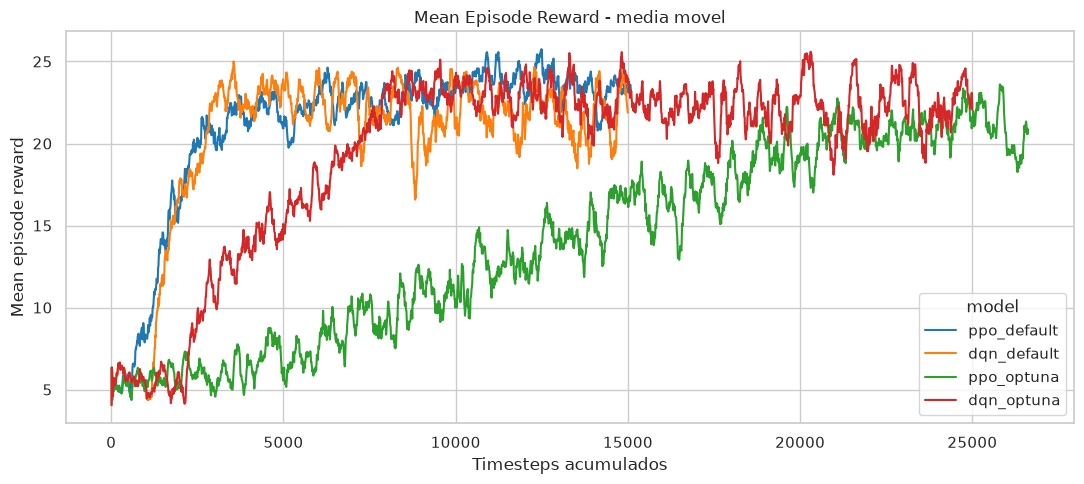

In [17]:
def load_monitor_curves():
    frames = []
    for monitor_file in RUN_MONITOR_DIR.glob("**/*.monitor.csv"):
        df = pd.read_csv(monitor_file, skiprows=1)
        df["model"] = monitor_file.parent.name
        df["episode"] = np.arange(1, len(df) + 1)
        df["timesteps"] = df["l"].cumsum()
        df["rolling_reward"] = df["r"].rolling(window=20, min_periods=1).mean()
        df["rolling_min_reward"] = df["r"].rolling(window=20, min_periods=1).min()
        frames.append(df)
    if not frames:
        return pd.DataFrame(columns=["model", "episode", "timesteps", "r", "rolling_reward", "rolling_min_reward"])
    return pd.concat(frames, ignore_index=True)

curves_df = load_monitor_curves()
curves_df.to_csv(RUN_RESULTS_DIR / "training_curves.csv", index=False)

selected_models = ["ppo_default", "dqn_default", "ppo_optuna", "dqn_optuna"]
plot_df = curves_df[curves_df["model"].isin(selected_models)].copy()
plot_df["model"] = pd.Categorical(plot_df["model"], categories=selected_models, ordered=True)
palette = dict(zip(selected_models, sns.color_palette("tab10", n_colors=len(selected_models))))



fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=plot_df, x="timesteps", y="rolling_reward", hue="model", hue_order=selected_models, palette=palette, ax=ax)
ax.set_title("Mean Episode Reward - media movel")
ax.set_xlabel("Timesteps acumulados")
ax.set_ylabel("Mean episode reward")
plt.tight_layout()
plt.savefig(RUN_FIGURES_DIR / "mean_reward_training.png", dpi=150)
plt.show()




## 11. Comparacao final


In [13]:
summary_display = results_df.copy()
for column in [
    "mean_reward",
    "std_reward",
    "min_reward",
    "max_reward",
    "mean_downlink_rate",
    "std_downlink_rate",
    "mean_power_watts",
    "std_power_watts",
    "mean_power_dbm",
    "std_power_dbm",
    "mean_sinr_linear",
    "std_sinr_linear",
    "mean_sinr_db",
    "std_sinr_db",
    "zero_power_fraction",
    "train_time_s",
]:
    summary_display[column] = summary_display[column].round(4)
summary_display.drop(columns=["params"])


,run_id,model,algorithm,training_type,seed,eval_episodes,mean_reward,std_reward,min_reward,max_reward,...,std_power_watts,mean_power_dbm,std_power_dbm,mean_sinr_linear,std_sinr_linear,mean_sinr_db,std_sinr_db,zero_power_fraction,train_time_s,device
0,20260720_210926_vasco_ppo_dqn,ppo_default,PPO,default,0,15,24.4482,3.4346,17.5037,28.3890,...,0.0000,23.0000,0.0000,21.6562,14.9501,12.4430,2.8139,0.0,457.6562,cuda
1,20260720_210926_vasco_ppo_dqn,dqn_default,DQN,default,0,15,23.1329,3.2583,16.8872,29.6264,...,0.0000,23.0000,0.0000,15.5902,7.5964,11.2911,2.5200,0.0,315.0241,cuda
2,20260720_210926_vasco_ppo_dqn,ppo_optuna,PPO,optuna,0,15,23.4171,2.2966,20.2814,28.9445,...,0.0000,23.0000,0.0000,17.3259,8.1945,11.9213,1.9942,0.0,836.4700,cuda
3,20260720_210926_vasco_ppo_dqn,dqn_optuna,DQN,optuna,0,15,23.4146,3.9333,11.8429,30.6245,...,0.0228,22.8227,0.6634,19.5984,11.0734,11.9437,3.2559,0.0,709.4675,cuda


,algorithm,reward_default,reward_optuna,delta_reward,downlink_default,downlink_optuna,delta_downlink,sinr_db_default,sinr_db_optuna,delta_sinr_db,power_dbm_default,power_dbm_optuna,delta_power_dbm,train_time_s_default,train_time_s_optuna
0,DQN,23.1329,23.4146,0.2817,2.3133,2.3415,0.0282,11.2911,11.9437,0.6526,23.0,22.8227,-0.1773,315.0241,709.4675
1,PPO,24.4482,23.4171,-1.0311,2.4448,2.3417,-0.1031,12.4430,11.9213,-0.5217,23.0,23.0000,0.0000,457.6562,836.4700


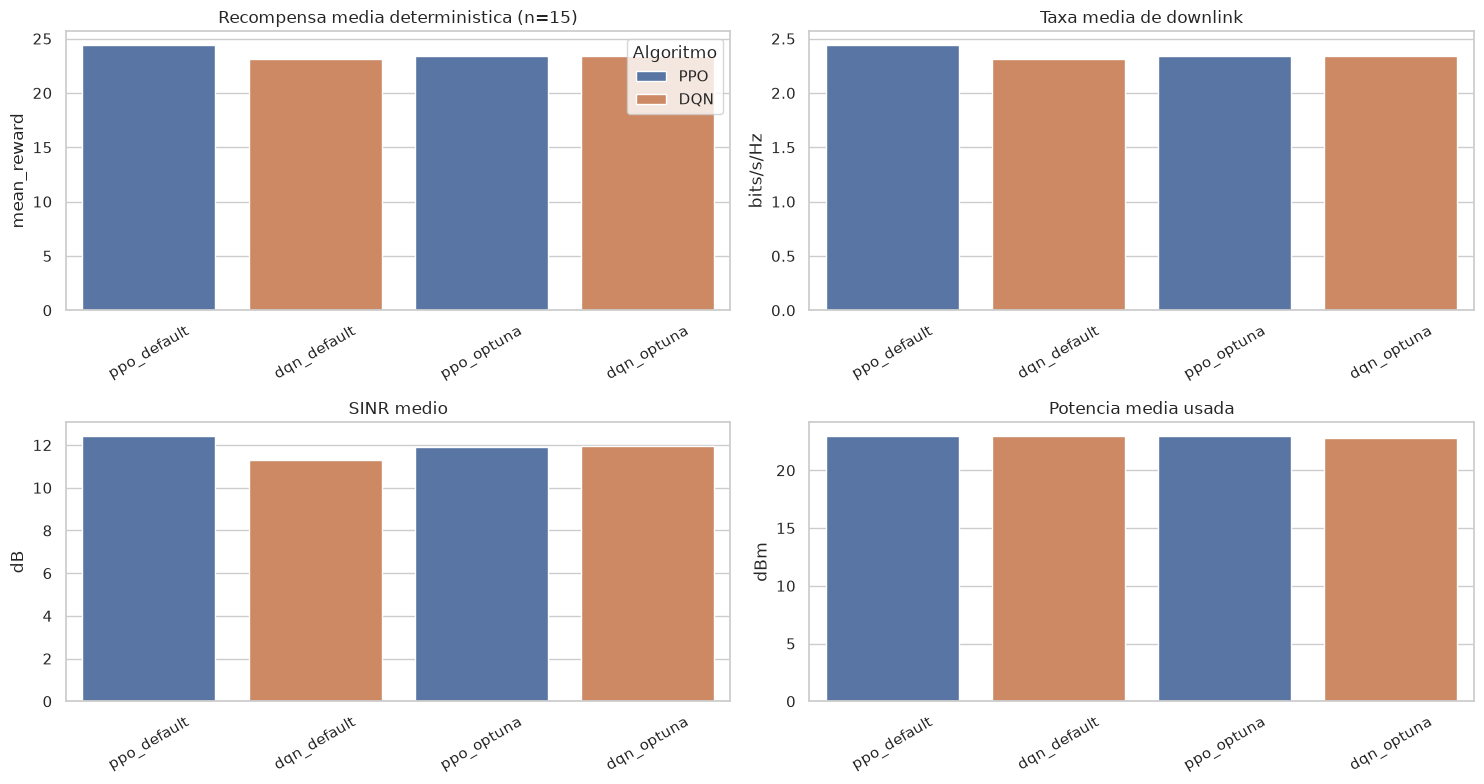

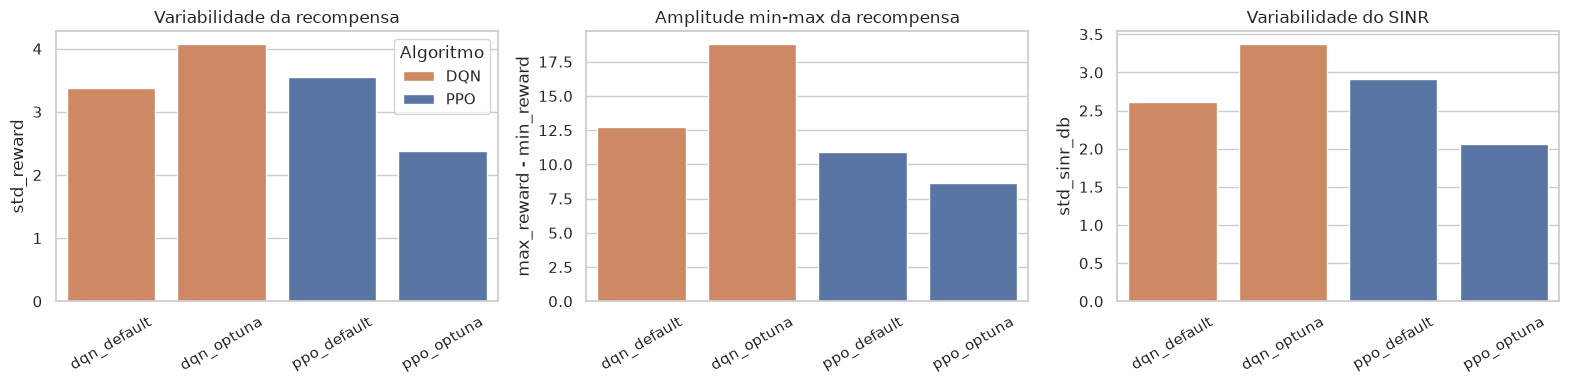

In [19]:
evaluation_df = pd.DataFrame(evaluation_records)
if evaluation_df.empty and (RUN_RESULTS_DIR / "evaluation_episodes.csv").exists():
    evaluation_df = pd.read_csv(RUN_RESULTS_DIR / "evaluation_episodes.csv")

comparison_df = results_df.copy()
comparison_df["reward_sem"] = comparison_df["std_reward"] / np.sqrt(comparison_df["eval_episodes"])
comparison_df["model"] = pd.Categorical(
    comparison_df["model"],
    categories=["ppo_default", "dqn_default", "ppo_optuna", "dqn_optuna"],
    ordered=True,
)
comparison_df = comparison_df.sort_values("model")
labels = comparison_df["model"].astype(str).tolist()

base_df = comparison_df[comparison_df["training_type"] == "default"].set_index("algorithm")
tuned_df = comparison_df[comparison_df["training_type"] == "optuna"].set_index("algorithm")
comparison_rows = []
for algorithm in sorted(set(base_df.index).intersection(tuned_df.index)):
    base = base_df.loc[algorithm]
    tuned = tuned_df.loc[algorithm]
    comparison_rows.append({
        "algorithm": algorithm,
        "reward_default": base["mean_reward"],
        "reward_optuna": tuned["mean_reward"],
        "delta_reward": tuned["mean_reward"] - base["mean_reward"],
        "downlink_default": base["mean_downlink_rate"],
        "downlink_optuna": tuned["mean_downlink_rate"],
        "delta_downlink": tuned["mean_downlink_rate"] - base["mean_downlink_rate"],
        "sinr_db_default": base["mean_sinr_db"],
        "sinr_db_optuna": tuned["mean_sinr_db"],
        "delta_sinr_db": tuned["mean_sinr_db"] - base["mean_sinr_db"],
        "power_dbm_default": base["mean_power_dbm"],
        "power_dbm_optuna": tuned["mean_power_dbm"],
        "delta_power_dbm": tuned["mean_power_dbm"] - base["mean_power_dbm"],
        "train_time_s_default": base["train_time_s"],
        "train_time_s_optuna": tuned["train_time_s"],
    })
algorithm_comparison = pd.DataFrame(comparison_rows).round(4)
display(algorithm_comparison)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
metric_plots = [
    ("mean_reward", f"Recompensa media deterministica (n={EVAL_EPISODES})", "mean_reward"),
    ("mean_downlink_rate", "Taxa media de downlink", "bits/s/Hz"),
    ("mean_sinr_db", "SINR medio", "dB"),
    ("mean_power_dbm", "Potencia media usada", "dBm"),
]
palette = {"PPO": sns.color_palette("deep")[0], "DQN": sns.color_palette("deep")[1]}

for ax, (metric, title, ylabel) in zip(axes.flat, metric_plots):
    sns.barplot(data=comparison_df, x="model", y=metric, hue="algorithm", dodge=False, palette=palette, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)
    if ax is not axes.flat[0]:
        ax.get_legend().remove()
    else:
        ax.legend(title="Algoritmo")

plt.tight_layout()
plt.savefig(RUN_FIGURES_DIR / "final_comparison.png", dpi=150)
plt.show()





stability_df = pd.read_csv(RUN_RESULTS_DIR / "stability_summary.csv")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(data=stability_df, x="model", y="std_reward", hue="algorithm", dodge=False, palette=palette, ax=axes[0])
axes[0].set_title("Variabilidade da recompensa")
axes[0].set_xlabel("")
axes[0].set_ylabel("std_reward")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Algoritmo")

reward_range = stability_df.assign(reward_range=stability_df["max_reward"] - stability_df["min_reward"])
sns.barplot(data=reward_range, x="model", y="reward_range", hue="algorithm", dodge=False, palette=palette, ax=axes[1])
axes[1].set_title("Amplitude min-max da recompensa")
axes[1].set_xlabel("")
axes[1].set_ylabel("max_reward - min_reward")
axes[1].tick_params(axis="x", rotation=30)
axes[1].get_legend().remove()

sns.barplot(data=stability_df, x="model", y="std_sinr_db", hue="algorithm", dodge=False, palette=palette, ax=axes[2])
axes[2].set_title("Variabilidade do SINR")
axes[2].set_xlabel("")
axes[2].set_ylabel("std_sinr_db")
axes[2].tick_params(axis="x", rotation=30)
axes[2].get_legend().remove()
plt.tight_layout()
plt.savefig(RUN_FIGURES_DIR / "stability_summary.png", dpi=150)
plt.show()


## 12. Conclusão



A metrica principal do ambiente e a recompensa, que corresponde a taxa media de downlink em bits/s/Hz ao longo dos passos do episodio. As metricas de potencia e SINR ajudam a interpretar se o ganho de recompensa veio de uma alocacao de potencia mais eficiente ou apenas de maior potencia transmitida.


In [16]:
best_model = results_df.sort_values("mean_reward", ascending=False).iloc[0]
print("Run ID:", RUN_ID)
print("Resultados da execucao:", RUN_RESULTS_DIR)
print("Figuras da execucao:", RUN_FIGURES_DIR)
print("Modelos da execucao:", RUN_MODELS_DIR)

print("Melhor modelo:", best_model["model"])
print("Recompensa media:", round(best_model["mean_reward"], 4))
print("Desvio da recompensa:", round(best_model["std_reward"], 4))
print("Taxa media de downlink:", round(best_model["mean_downlink_rate"], 4))
print("Potencia media usada (W):", round(best_model["mean_power_watts"], 6))
print("Potencia media usada (dBm):", round(best_model["mean_power_dbm"], 4))
print("SINR medio (linear):", round(best_model["mean_sinr_linear"], 6))
print("SINR medio (dB):", round(best_model["mean_sinr_db"], 4))

print("Comparacao default vs Optuna:")
display(algorithm_comparison)

print("Melhores parametros PPO:")
print(study_ppo.best_params)

print("Melhores parametros DQN:")
print(study_dqn.best_params)


Run ID: 20260720_210926_vasco_ppo_dqn
Resultados da execucao: /home/juan/documents/projeto_ic_MIMO/VASCO_final_project/results/runs/20260720_210926_vasco_ppo_dqn
Figuras da execucao: /home/juan/documents/projeto_ic_MIMO/VASCO_final_project/figures/runs/20260720_210926_vasco_ppo_dqn
Modelos da execucao: /home/juan/documents/projeto_ic_MIMO/VASCO_final_project/models/runs/20260720_210926_vasco_ppo_dqn
Melhor modelo: ppo_default
Recompensa media: 24.4482
Desvio da recompensa: 3.4346
Taxa media de downlink: 2.4448
Potencia media usada (W): 0.199526
Potencia media usada (dBm): 23.0
SINR medio (linear): 21.656195
SINR medio (dB): 12.443
Comparacao default vs Optuna:


,algorithm,reward_default,reward_optuna,delta_reward,downlink_default,downlink_optuna,delta_downlink,sinr_db_default,sinr_db_optuna,delta_sinr_db,power_dbm_default,power_dbm_optuna,delta_power_dbm,train_time_s_default,train_time_s_optuna
0,DQN,23.1329,23.4146,0.2817,2.3133,2.3415,0.0282,11.2911,11.9437,0.6526,23.0,22.8227,-0.1773,315.0241,709.4675
1,PPO,24.4482,23.4171,-1.0311,2.4448,2.3417,-0.1031,12.4430,11.9213,-0.5217,23.0,23.0000,0.0000,457.6562,836.4700


Melhores parametros PPO:
{'n_steps': 2048, 'batch_size': 128, 'learning_rate': 5.432176219989315e-05, 'gamma': 0.9517645562137688, 'gae_lambda': 0.9009195079319672, 'clip_range': 0.21403935408357594, 'ent_coef': 0.004386015134623203}
Melhores parametros DQN:
{'learning_rate': 0.00015236917933309359, 'buffer_size': 50000, 'learning_starts': 2000, 'batch_size': 256, 'gamma': 0.9973109838451991, 'train_freq': 1, 'gradient_steps': 1, 'target_update_interval': 1000, 'exploration_fraction': 0.3381093110072262, 'exploration_final_eps': 0.025674728164226612}
